# Hotel Booking Cancellation Prediction
# Sprint 1 — Data Understanding & Preprocessing

## Business Problem
Hotels lose significant revenue due to booking cancellations.  
The goal of this project is to analyze customer booking behavior and prepare a clean dataset for machine learning prediction.

## Sprint 1 Objectives
- Data Loading
- Data Inspection
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Outlier Treatment
- Feature Encoding
- Feature Scaling
- Train-Test Split

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Step 1: Load Dataset

In [80]:
df = pd.read_csv(r"C:\Users\byath\Machine Learning\ML_Sprint-1\hotel_bookings.csv")

In [81]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [82]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset Shape: (119390, 32)
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']



## Observation
- Dataset contains hotel booking records.
- Target variable is `is_canceled`.
- Dataset includes both numerical and categorical variables.
- Classification problem.


# Step 2: Initial Data Inspection

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [84]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


# Missing values

In [85]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

# Duplicate rows

In [86]:
df.duplicated().sum()

np.int64(31994)

## Observations
- `company` and `agent` contain large missing values.
- `country` and `children` contain smaller missing values.
- Missing values may indicate direct bookings without intermediaries.


# Step 3: Data Cleaning

### Remove duplicates

In [87]:
df = df.drop_duplicates()
df.shape

(87396, 32)

### Handle missing values

In [88]:
df['children'].fillna(df['children'].median(), inplace=True)

df['country'].fillna(df['country'].mode()[0], inplace=True)

df['agent'].fillna(0, inplace=True)

df['company'].fillna(0, inplace=True)

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119385    0.0
119386    0.0
119387    0.0
119388    0.0
119389    0.0
Name: company, Length: 87396, dtype: float64

In [89]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [90]:
# Verify missing values
df.isnull().sum().sort_values(ascending=False).head()

company               82137
agent                 12193
country                 452
children                  4
arrival_date_month        0
dtype: int64


## Observation
- Median used for children.
- Mode used for country.
- Agent and company replaced with 0.
- Duplicate records removed successfully.
- Missing values handled based on business logic instead of blindly dropping rows.


# Step 4: Feature Engineering

### Convert date column

In [91]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

### Extract date features

In [92]:
df['reservation_year'] = df['reservation_status_date'].dt.year
df['reservation_month'] = df['reservation_status_date'].dt.month
df['reservation_day'] = df['reservation_status_date'].dt.day

In [93]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,reservation_year,reservation_month,reservation_day
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015,7,1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015,7,1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015,7,2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015,7,2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015,7,3



## Observation
- Seasonality can influence booking cancellations.
- Date features help models understand seasonal and booking trends.


# Step 5: Exploratory Data Analysis

## Univariate Analysis

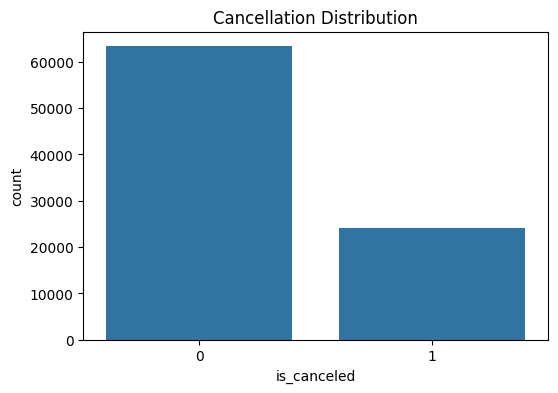

In [94]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df)
plt.title("Cancellation Distribution")
plt.show()


### Observation
- Most bookings are not canceled.


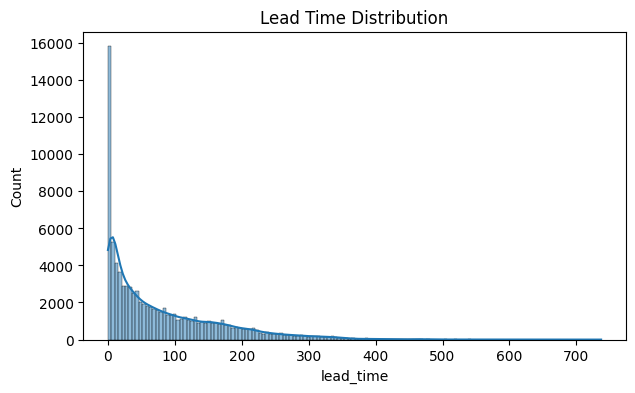

Skewness: 1.431773771483355


In [95]:
plt.figure(figsize=(7,4))
sns.histplot(df['lead_time'], kde=True)
plt.title("Lead Time Distribution")
plt.show()

print("Skewness:", df['lead_time'].skew())


### Observation
- Majority bookings are not cancelled.
- Lead time is highly right skewed & positively skewed.
- Few customers book extremely early.

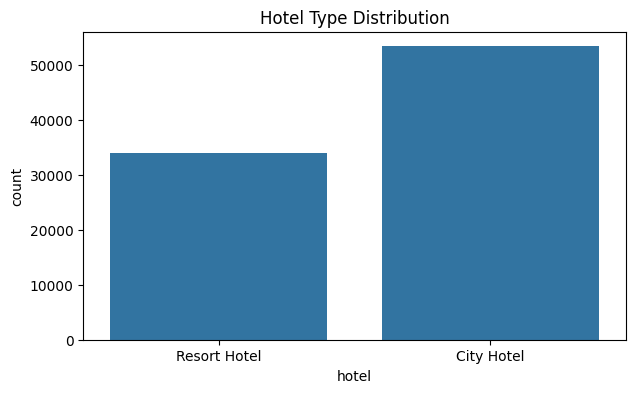

In [96]:
plt.figure(figsize=(7,4))
sns.countplot(x='hotel', data=df)
plt.title("Hotel Type Distribution")
plt.show()


### Observation
- City hotels receive more bookings than resort hotels.


## Bivariate Analysis

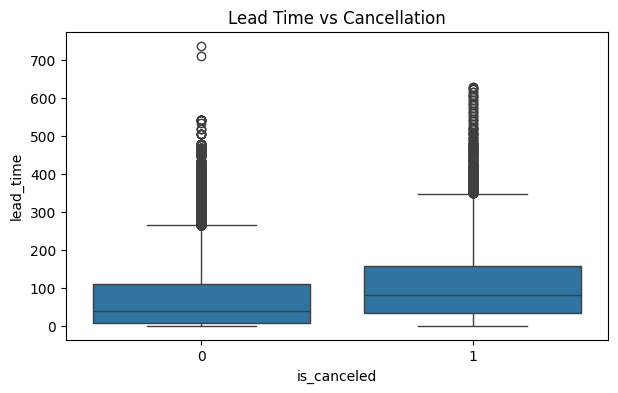

In [97]:
plt.figure(figsize=(7,4))
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()


### Observation
- Customers with higher lead time tend to cancel more.


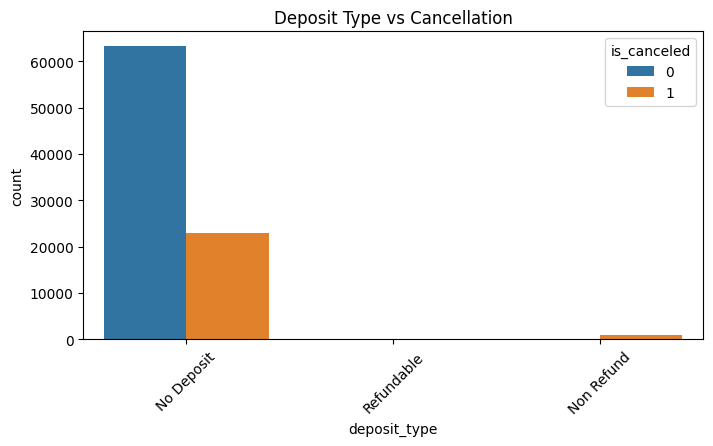

In [98]:
plt.figure(figsize=(8,4))
sns.countplot(x='deposit_type', hue='is_canceled', data=df)
plt.xticks(rotation=45)
plt.title("Deposit Type vs Cancellation")
plt.show()


### Observation
- Deposit type strongly impacts cancellation behavior.


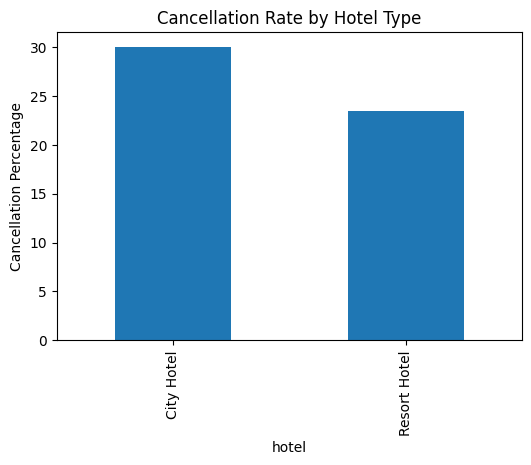

In [47]:
cancel_rate = df.groupby('hotel')['is_canceled'].mean()*100

cancel_rate.plot(kind='bar', figsize=(6,4))
plt.ylabel("Cancellation Percentage")
plt.title("Cancellation Rate by Hotel Type")
plt.show()


### Observation
- City hotels have higher cancellation rates.
- Higher lead time increases cancellation risk.
- Deposit type impacts cancellation behavior.

## Multivariate Analysis

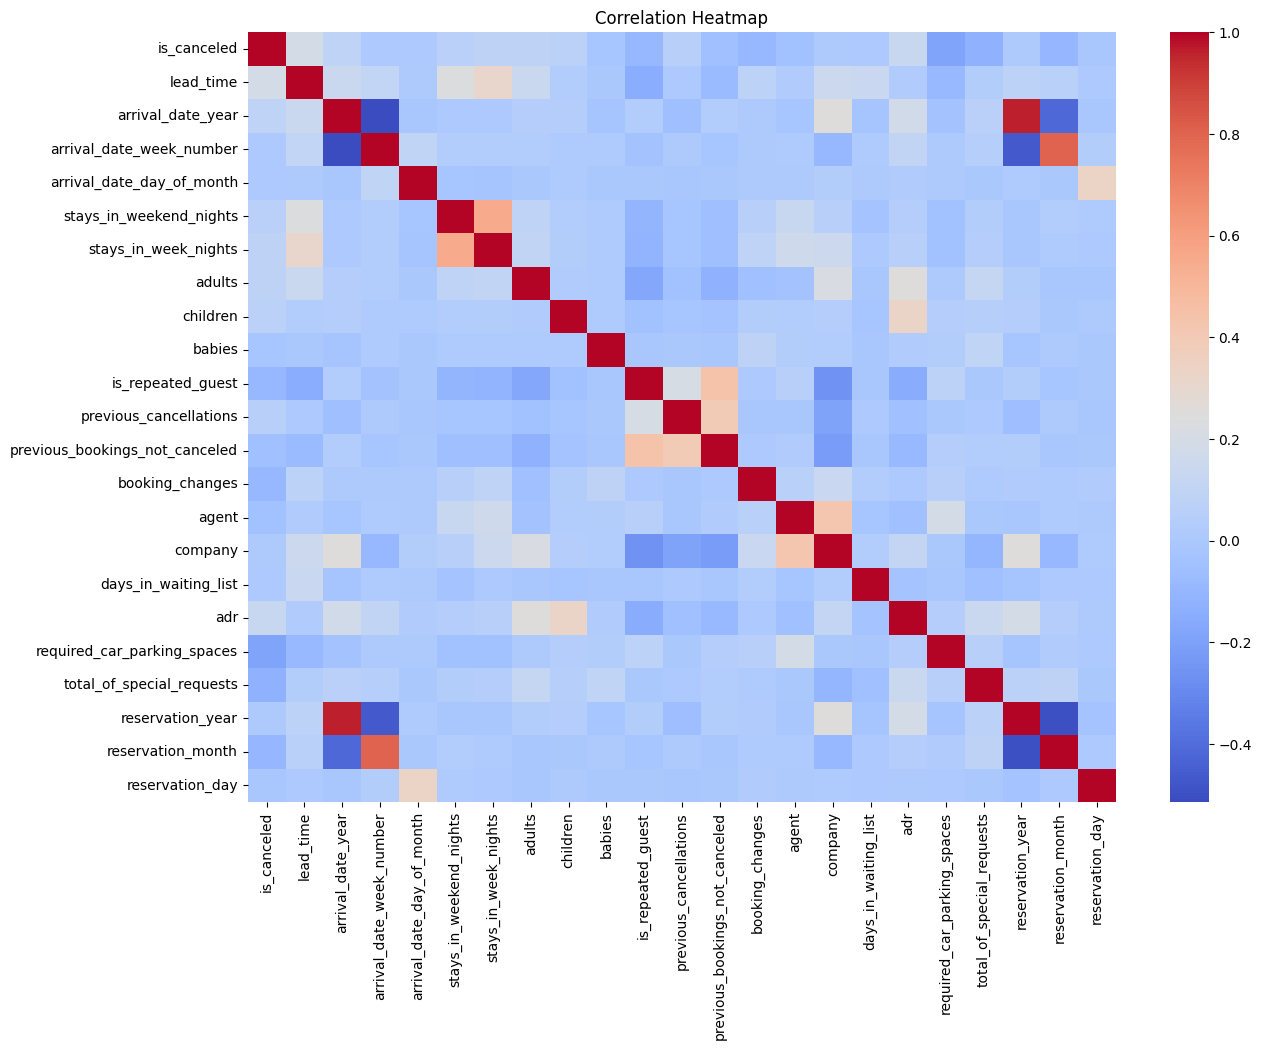

In [99]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Observation
- No severe multicollinearity detected among numerical features.


# Step 6: Outlier Detection & Treatment

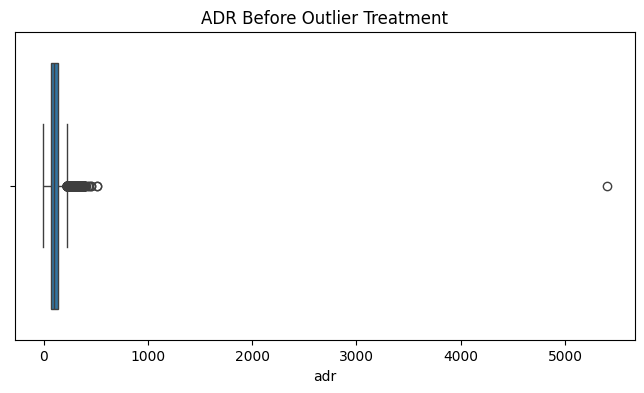

In [100]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['adr'])
plt.title("ADR Before Outlier Treatment")
plt.show()

In [101]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['adr'] = np.where(df['adr'] > upper_bound, upper_bound, df['adr'])

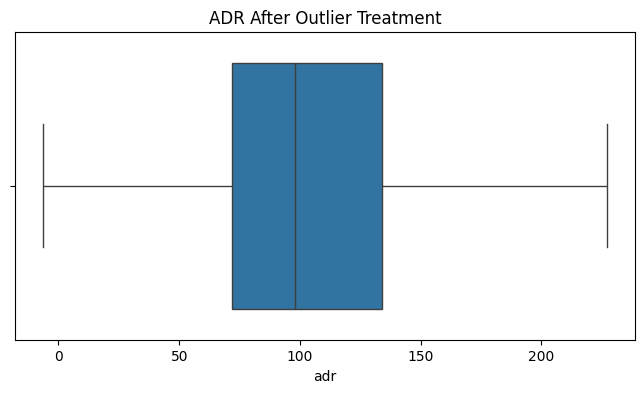

In [102]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['adr'])
plt.title("ADR After Outlier Treatment")
plt.show()

## Observation
- ADR contained extreme values which were capped using IQR method.


# Step 7: Feature Encoding

In [52]:
# Drop leakage column
df.drop(['reservation_status'], axis=1, inplace=True)

cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,reservation_year,reservation_month,reservation_day
0,1,0,342,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,3,0,NaN,NaN,0,2,0.0,0,0,2015-07-01,2015,7,1
1,1,0,737,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,4,0,NaN,NaN,0,2,0.0,0,0,2015-07-01,2015,7,1
2,1,0,7,2015,5,27,1,0,1,1,0.0,0,0,59,3,1,0,0,0,0,2,0,0,NaN,NaN,0,2,75.0,0,0,2015-07-02,2015,7,2
3,1,0,13,2015,5,27,1,0,1,1,0.0,0,0,59,2,0,0,0,0,0,0,0,0,304.0,NaN,0,2,75.0,0,0,2015-07-02,2015,7,2
4,1,0,14,2015,5,27,1,0,2,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,240.0,NaN,0,2,98.0,0,1,2015-07-03,2015,7,3


In [103]:
df.drop(['reservation_status','reservation_status_date'],
        axis=1,
        inplace=True)

if 'reservation_year' in df.columns:
    if df['reservation_year'].nunique() <= 1:
        df.drop('reservation_year', axis=1, inplace=True)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_year,reservation_month,reservation_day
0,1,0,342,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,3,0,NaN,NaN,0,2,0.0,0,0,2015,7,1
1,1,0,737,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,4,0,NaN,NaN,0,2,0.0,0,0,2015,7,1
2,1,0,7,2015,5,27,1,0,1,1,0.0,0,0,59,3,1,0,0,0,0,2,0,0,NaN,NaN,0,2,75.0,0,0,2015,7,2
3,1,0,13,2015,5,27,1,0,1,1,0.0,0,0,59,2,0,0,0,0,0,0,0,0,304.0,NaN,0,2,75.0,0,0,2015,7,2
4,1,0,14,2015,5,27,1,0,2,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,240.0,NaN,0,2,98.0,0,1,2015,7,3



## Observation
- Label Encoding converts categorical features into numerical values for machine learning.


# Step 8: Scaling & Train-Test Split

In [104]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print("Non Numeric Columns:")
print(X.select_dtypes(exclude='number').columns)

Non Numeric Columns:
Index([], dtype='str')


In [106]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [107]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)


Train Shape: (69916, 32)
Test Shape: (17480, 32)



## Observation
- Scaling applied only after train-test split to avoid data leakage.


# Final Sprint 1 observation
## Key Business Insights
1. Lead time strongly affects cancellation probability.
2. Deposit type strongly affects cancellations.
3. City hotels show higher cancellation rates.
4. Pricing contains extreme outliers.
5. ADR contains extreme values.
6. Booking patterns are predictable using ML.